# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:

from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt


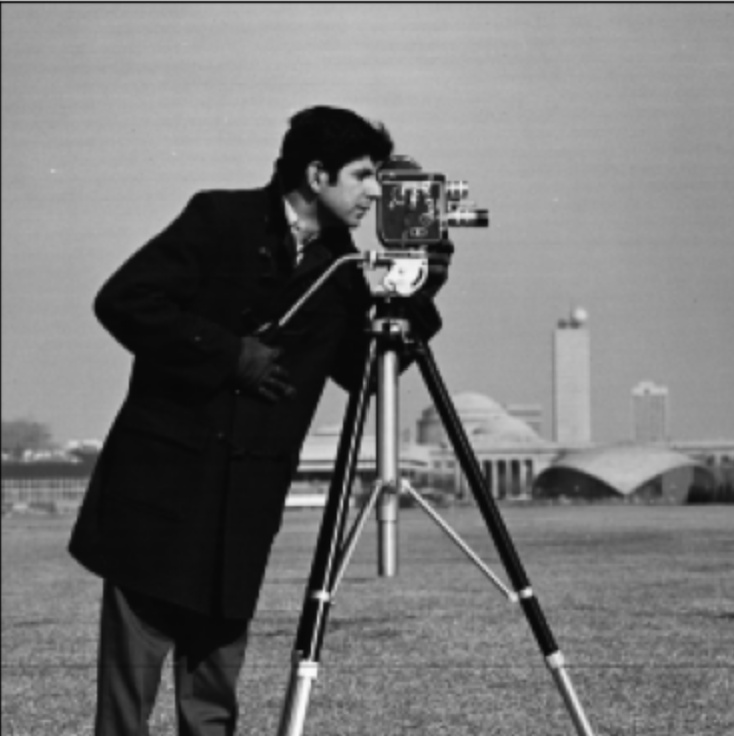

In [6]:
# Load image
image = Image.open("new_image.jpg")

# Display image
display(image)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [8]:
# Get the size of the image
width, height = image.size

print("Original size:", image.size)

# scaling factors
cx = 2
cy = 2


Original size: (734, 736)


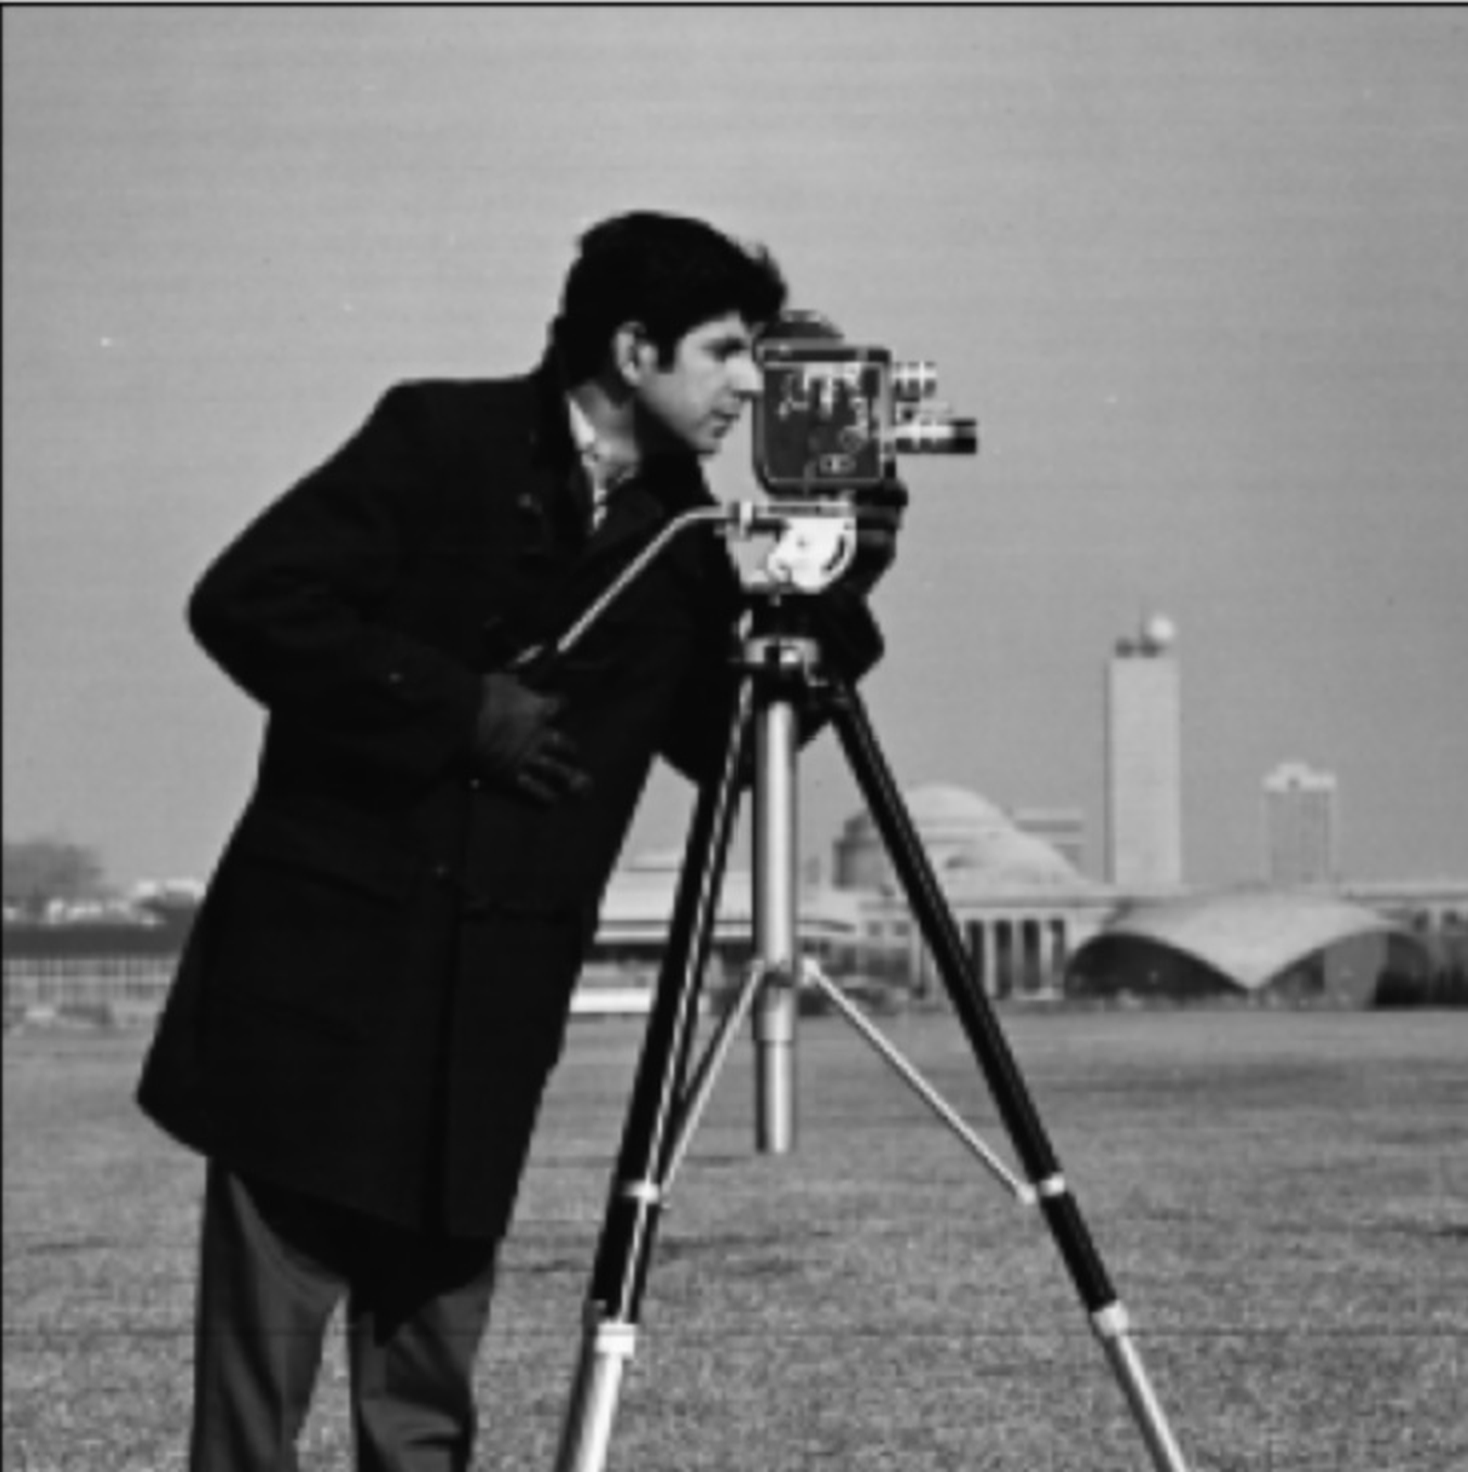

In [10]:

scaled_image = image.resize(
    (width * cx, height * cy),
    Image.Resampling.LANCZOS
)

display(scaled_image)



In [11]:

scaled_image.save("task1_1_scaled.jpg")

print("Original size:", image.size)
print("Scaled size:", scaled_image.size)


Original size: (734, 736)
Scaled size: (1468, 1472)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

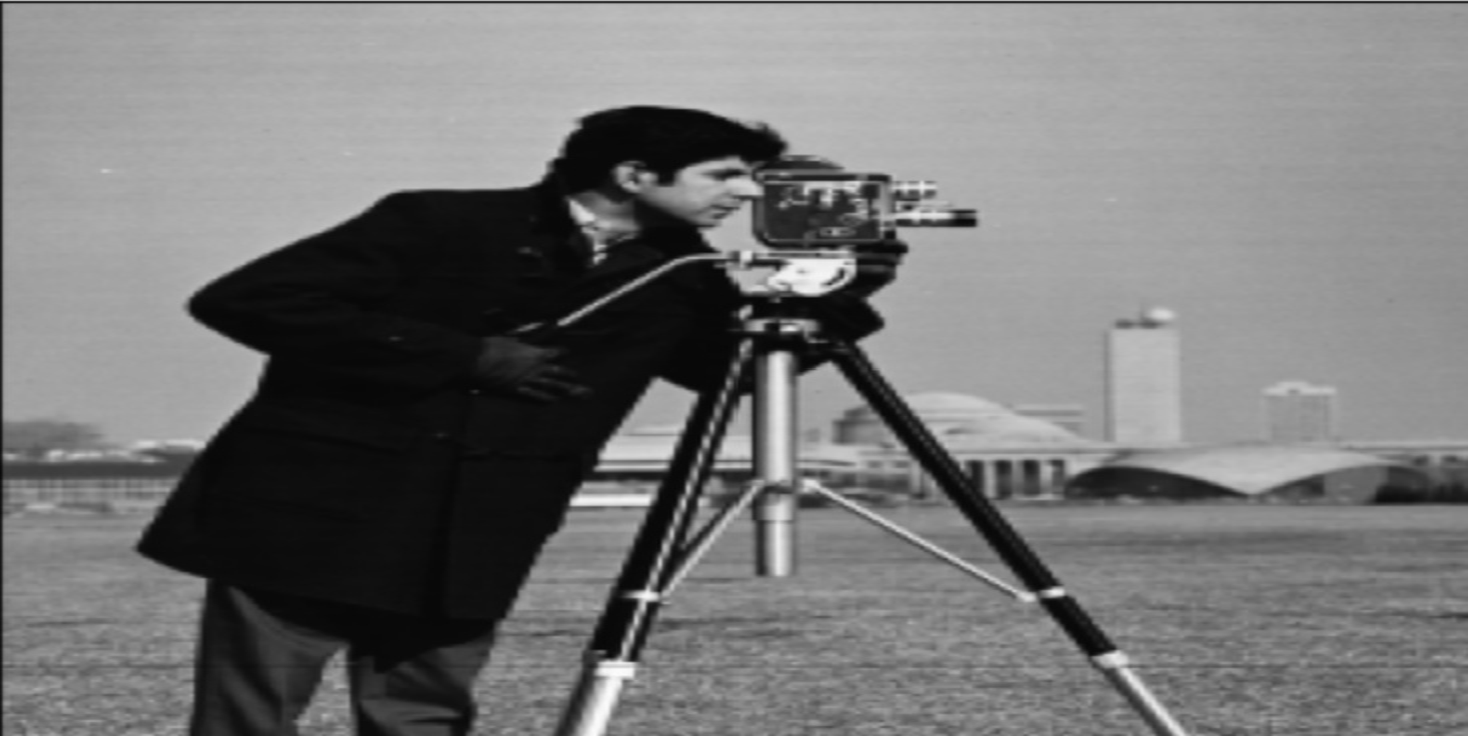

Original size: (734, 736)
Non-uniform size: (1468, 736)


In [12]:
# Non-uniform scale (cx=2, cy=1)
cx = 2
cy = 1

non_uniform_image = image.resize(
    (width * cx, height * cy),
    Image.Resampling.LANCZOS
)

display(non_uniform_image)

print("Original size:", image.size)
print("Non-uniform size:", non_uniform_image.size)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

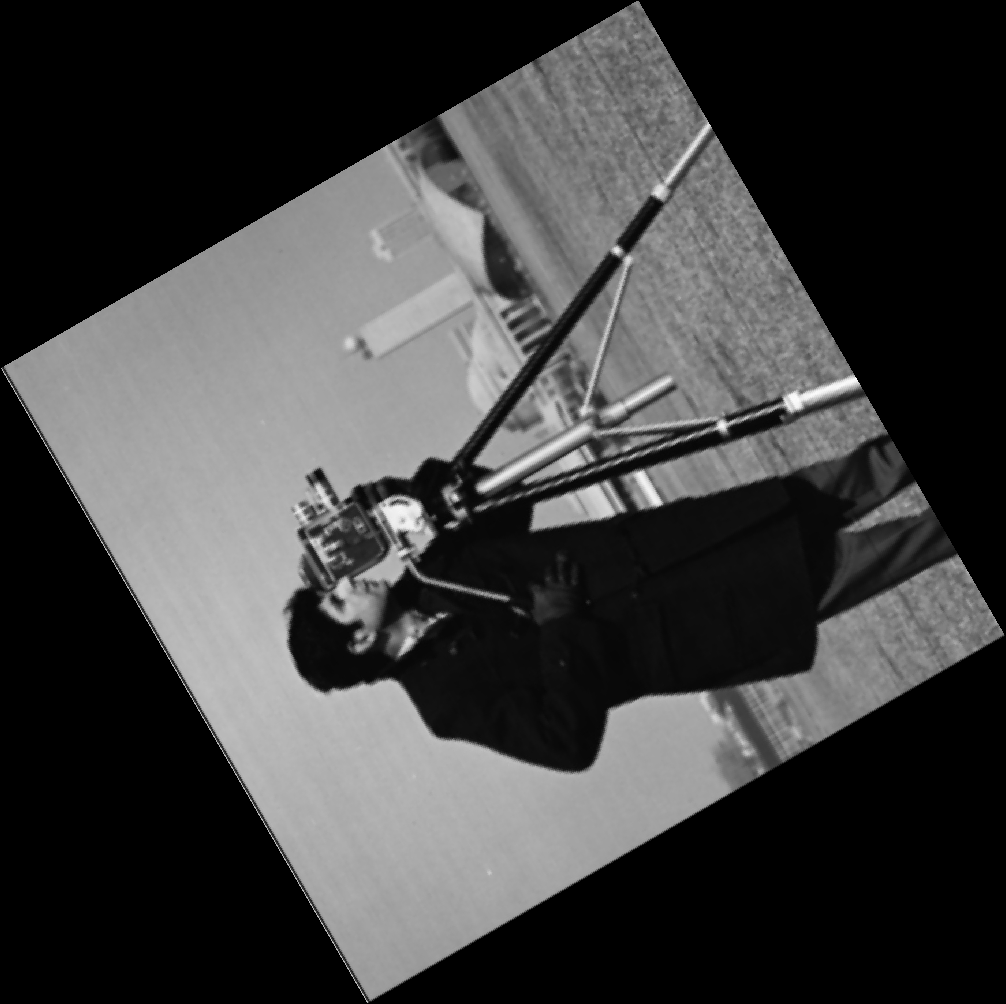

In [13]:

rotated_image = image.rotate(
    120,
    expand=True
)

display(rotated_image)

### 3. Shear

In [14]:
width, height = image.size

print("Width:", width)
print("Height:", height)

Width: 734
Height: 736


In [15]:

shear_factor = 0.5

# X-axis shear
shx = shear_factor
shy = 0

shear_matrix = (
    1, -shx, 0,
    0, 1, 0
)

print("Shear factor:", shear_factor)
print("Shear matrix:", shear_matrix)

Shear factor: 0.5
Shear matrix: (1, -0.5, 0, 0, 1, 0)


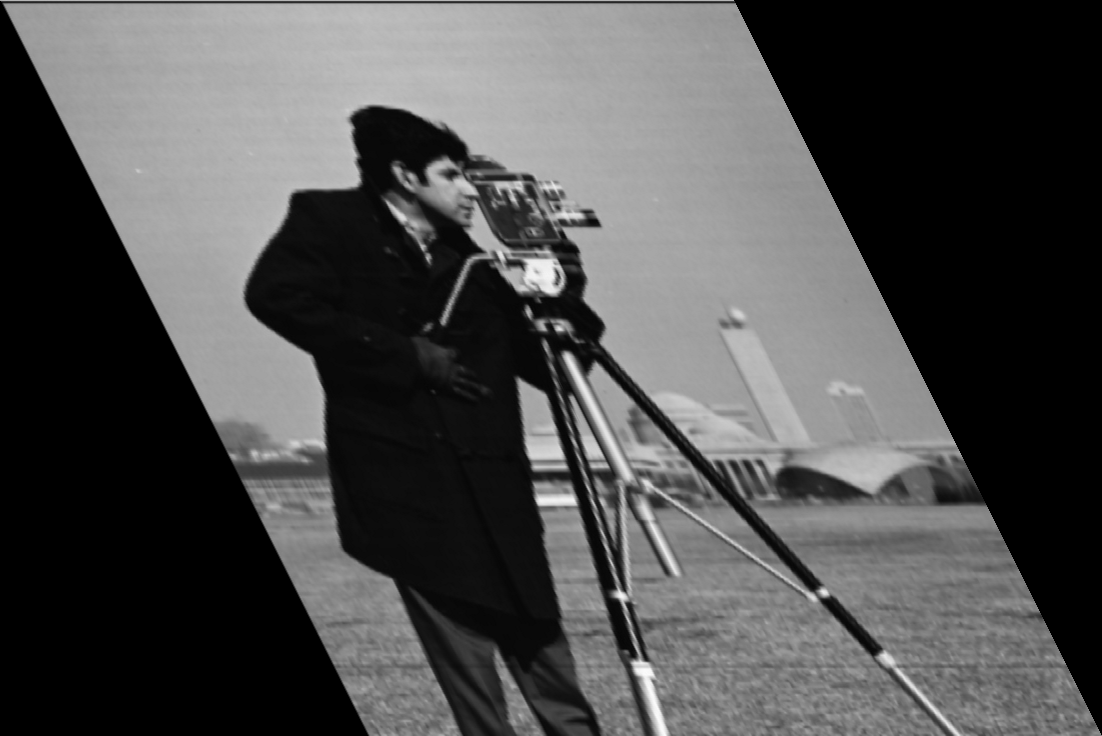

Sheared size: (1102, 736)


In [16]:
new_width = int(width + shear_factor * height)
new_height = height

sheared_image = image.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)

display(sheared_image)

print("Sheared size:", sheared_image.size)


In [17]:

sheared_image.save("task1_3_sheared.jpg")

print("Sheared image saved successfully.")
print("Original size:", image.size)
print("Sheared size:", sheared_image.size)

Sheared image saved successfully.
Original size: (734, 736)
Sheared size: (1102, 736)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

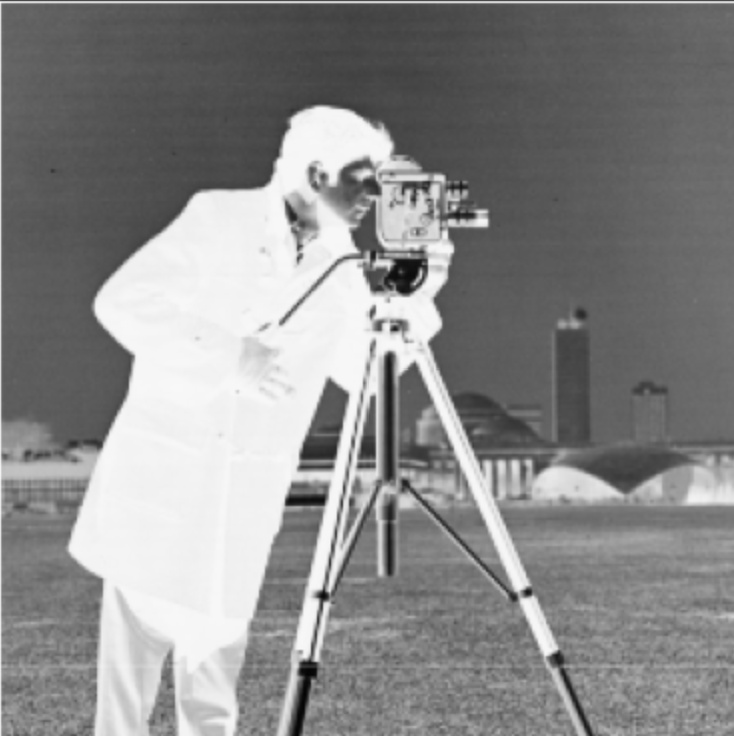

In [18]:
arr = np.array(image)

negative_arr = 255 - arr

negative_image = Image.fromarray(negative_arr.astype(np.uint8))

display(negative_image)


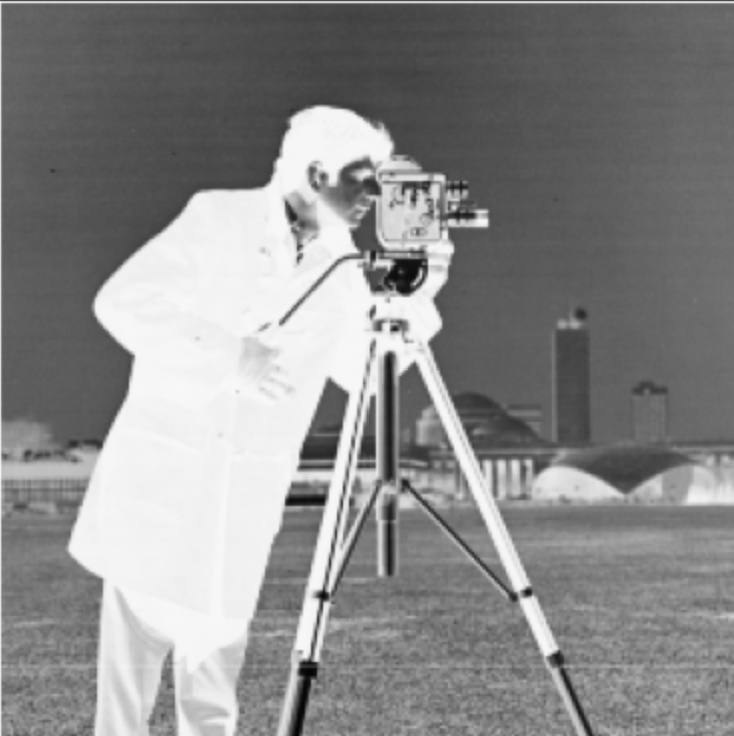

In [19]:
negative_image_pil = ImageOps.invert(image.convert("L"))

display(negative_image_pil)

In [20]:
# ── 2. Log transformation ──────────────────────────

# Convert image to grayscale
gray_image = image.convert("L")

# Convert to NumPy float array
arr = np.array(gray_image).astype(np.float32)

# s = c * log(1 + r)
c = 255 / np.log(1 + 255)

print("c =", c)


c = 45.98590442833571


In [ ]:

# ── 3. Power-law / Gamma correction ───────────────
